In [1]:
##### Plots feature importance for final RF models

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
##### SET-UP

# Get the current working directory
cd = Path.cwd().parent 

# import models
capital = pd.read_csv(f'{cd}/Results/RF_models/capital_rf_spatial_CV/feature_importance.csv')
labor = pd.read_csv(f'{cd}/Results/RF_models/labor_rf_spatial_CV/feature_importance.csv')

# set directory
FIG_DIR = Path(f"{cd}/Figures/")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
### Prep data

# final var names 
FEATURE_NAME_MAP = {
    "rtv_log_ruminants_share_base_100_production_tonnes":     "ruminant_share_production",
    "rtv_log_tonnes_production_per_million_HA":               "tonnes_production_per_HA",
    "rtv_log_share_base_100_large_field":                      "share_fields_large",
    "rtv_log_cattle_density_per_100_km2":                      "cattle_density",
    "rtv_log_roots_tubers_share_base_100_production_tonnes":   "roots_tubbers_share_production",
    "rtv_log_livestock_density_LU_per_100_km2":                "all_livestock_density",
    "rtv_log_vegetables_share_base_100_production_tonnes":     "vegetables_share_production",
    "rtv_log_fruits_share_base_100_production_tonnes":         "fruits_share_production",
    "rtv_log_average_travel_time_port":                        "average_travel_time_port",
    "rtv_log_cereals_share_base_100_production_tonnes":        "cereals_share_production",
    "rtv_log_pop_density_people_per_100_km2":                  "pop_density",
    "rtv_log_sheep_density_per_100_km2":                       "sheep_density",
    "rtv_log_USD_production_per_million_HA":                  "USD_production_per_HA",
    "rtv_log_share_base_100_with_nightlights":                 "share_with_nightlights",
    "rtv_log_crop_intensity":                                  "average_cropping_intensity",
    "rtv_log_pct_base_100_cropland_irrigated":                 "share_cropland_irrigated",
    "rtv_log_rest_of_crops_share_base_100_production_tonnes":  "rest_of_crops_share_production",
    "rtv_log_sugar_crops_share_base_100_production_tonnes":    "sugar_crops_share_production",
    "rtv_log_pct_base_100_GDP_ag":                             "ag_share_GDP",
}

capital["name"] = capital["feature"].map(FEATURE_NAME_MAP)
labor["name"] = labor["feature"].map(FEATURE_NAME_MAP)

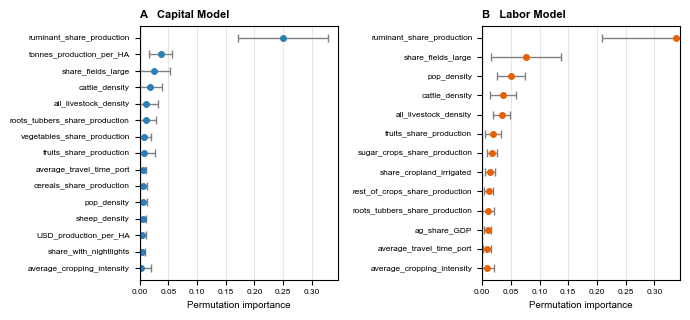

In [4]:
#### Feature importance: capital vs labor (permutation importance)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]

fig, axes = plt.subplots(1, 2, figsize=(7, max(len(capital), len(labor)) * 0.18 + 0.6), sharex=True)

panel_colors = ["#2c7fb8", "#e66101"]
panel_labels = ["A", "B"]

def plot_feature_importance(ax, df, panel_label, panel_title, color):
    df_sorted = df.sort_values("permutation_mean", ascending=True)

    ax.errorbar(
        df_sorted["permutation_mean"], df_sorted["name"],
        xerr=df_sorted["permutation_std"],
        fmt="o", color=color, ecolor="grey", elinewidth=1, capsize=3,
        markersize=4, zorder=2
    )

    ax.axvline(0, color="black", linewidth=0.8, zorder=1)
    ax.set_title(f"{panel_label}   {panel_title}", loc="left", fontsize=8, weight="bold")
    ax.set_xlabel("Permutation importance", fontsize=7)
    ax.tick_params(axis="both", labelsize=6)
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim(left=0)

plot_feature_importance(axes[0], capital, panel_labels[0], "Capital Model", panel_colors[0])
plot_feature_importance(axes[1], labor, panel_labels[1], "Labor Model", panel_colors[1])

plt.tight_layout()
plt.show()

fig.savefig(FIG_DIR / "SI_fig_5_feature_importance.tiff", dpi=300, bbox_inches="tight")